In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
X = np.array([1,2,3,4,5,6,7,8,9,10])

Y = np.array([1.5,1.8,3.2,3.9,5.1,5.8,6.9,8.2,8.8,10.1])


In [3]:
X_matrix=np.column_stack((np.ones(len(X)),X))

In [4]:
def gaussian_weights(query_point, X, tau):

    m = X.shape[0]

    weights = np.eye(m)

    for i in range(m):

        diff = query_point - X[i]

        weights[i,i] = np.exp(np.dot(diff,diff)/(-2*tau*tau))

    return weights

In [5]:
def locally_weighted_regression(query_point, X, Y, tau):

    W = gaussian_weights(query_point, X, tau)

    theta = np.linalg.inv(X.T @ W @ X) @ (X.T @ W @ Y)

    prediction = query_point @ theta

    return prediction

In [6]:
tau = 0.5

predictions = []

for point in X_matrix:

    predictions.append(
        locally_weighted_regression(point, X_matrix, Y, tau)
    )

predictions = np.array(predictions)

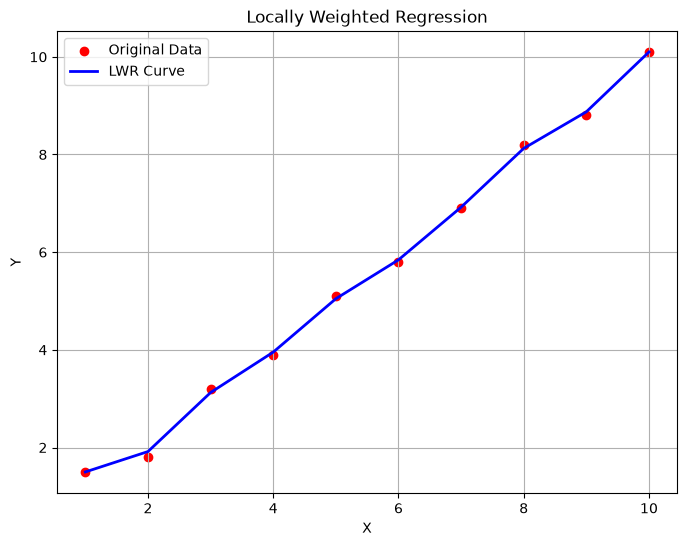

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y, color='red', label="Original Data")

plt.plot(X, predictions,
         color='blue',
         linewidth=2,
         label="LWR Curve")

plt.xlabel("X")

plt.ylabel("Y")

plt.title("Locally Weighted Regression")

plt.legend()

plt.grid(True)

plt.show()